In [2]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd

import numpy as np 


from scipy.stats import sem

In [3]:
DIR = Path("../../artifacts/2023-08-s10/experiments/basis-accuracy")

In [13]:
def load(dataset, arch, layer, basis_name, training_size=1.0, logit_mod="oneclass", basis_mode="centered", seeds=list(range(1, 5+1))):
    
    arr_dfs = []
    for seed in seeds:
        with open(DIR / f"{dataset}--ts{training_size}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
            
        
        df = pd.DataFrame(
            {
                "acc": data["arr_acc"],
                "k": data["arr_ks"],
            }
        )
        df["dims"] = data["dims"]

        # perhaps, we refactor it.
        df["original_acc"] = data["original_acc"]
        df["seed"] = seed
            
        arr_dfs.append(df)
    
    df = pd.concat(arr_dfs).groupby(by="k").agg({
        "acc": ["mean", "std"],
        "seed": ["count"],
        "original_acc": ["first"],
        "dims": ["first"]
    })
    
    
    assert (df["seed"]["count"] == df["seed"]["count"].values[0]).all()

    for col in ["original_acc", "dims"]:

        assert (df[col]["first"] == df[col]["first"].values[0]).all()

    return df.reset_index()

_df = load(
    dataset="cifar100-people", 
    arch="cifar100-resnet18-p1",
    layer="layer3", 
    basis_name="pca", 
    training_size=1.0,
)

_df[5:10]

k     acc            seed original_acc  dims
         mean       std count        first first
5   6  0.2828  0.003899     5         0.55   256
6   7  0.2744  0.005550     5         0.55   256
7   8  0.2656  0.004561     5         0.55   256
8   9  0.2620  0.001414     5         0.55   256
9  10  0.2720  0.002828     5         0.55   256

# Accuracy Curve Aggregated Over Seeds on CIFAR100-Resnet18-p1

In [14]:
def basis_displayname(basis_name):
    mapping = {
#         "random": "Random",
#         "act-recon": "Act",
#         "rel-recon": "Rel",
#         "pca": "PCA",
#         'pcaprca-recon': "PRCA"
    }

    return f"{mapping.get(basis_name, basis_name):15s}"

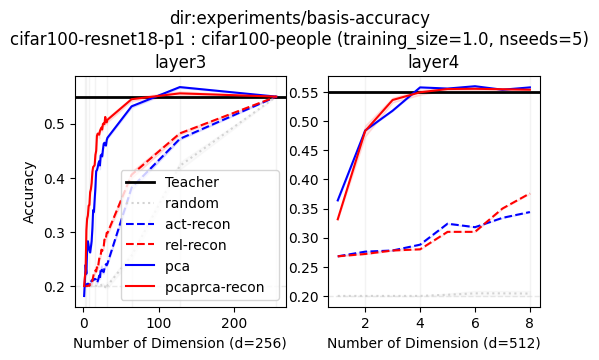

In [137]:
def accuracy_curve(
    arch, layers_and_factors,
    dataset,
    arr_bases = [
        "random",
        "act-recon",
        "rel-recon",
        "pca",
        "pcaprca-recon",
    ],
    logit_mod="oneclass",
    training_size=1.0
):

    
    seeds = list(range(1, 5+1))

        
    ncols = len(layers_and_factors)
    
    nseeds = len(seeds)
    plt.figure(figsize=(ncols * 3, 3))
    plt.suptitle("\n".join([
        "dir:" + "/".join(f"{DIR}".split("/")[-2:]),
        f"{arch} : {dataset} (training_size={training_size}, nseeds={nseeds})"
    ]), y=1.1)
    
    def color(basis_name):
        if basis_name in ["act-recon", "pca", "act-raw"]:
            return "blue"
        elif basis_name == "prca-recon":
            return "yellow"
        elif basis_name == "prca-abs":
            return "pink"
        elif basis_name in ["rel-recon", "pcaprca-recon"] or "rel" in basis_name or "prca" in basis_name:
            return "red"
        elif "random" == basis_name:
            return "lightgray"
        else:
            return "green"
            raise NotImplementedError(f"no color for `{basis_name}`")
            
    def ls(basis_name):
        if basis_name == "random":
            return ":"
        elif "act" in basis_name  or "rel" in basis_name:
            return "--"
        elif basis_name in ["prca-abs", "prca-recon", "prca-reconnaive"]:
            return "-."
        else:
            return "-"

        
    def marker(basis_name):
        if 'naive' in basis_name:
            return "."
        elif "raw" in basis_name:
            return "|"
        elif 'naive' in basis_name :
            return "d"
        else:
            return None
        
    
    for lix, (layer, factor) in enumerate(layers_and_factors):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        


        df = load(
            dataset=dataset,  arch=arch, layer=layer,  basis_name="random",  training_size=training_size,
            logit_mod=logit_mod,
                seeds=seeds
        )
        teacher_acc = df["original_acc"]["first"].values[0]
        
        d = df["dims"]["first"].values[0]
        k = df["k"].values
        
        selected = k <= d//factor
        

        for t in np.power(2, np.arange(1, np.ceil(np.log2(k[selected].max()))+1)):
            plt.axvline(t, ls="-", alpha=0.25, lw=1, color="lightgray")
        
        plt.axhline(teacher_acc, label="Teacher", color="k", lw=2, ls="-")
        plt.axhline(0.2, ls="--", lw=1, color="lightgray", alpha=0.5)
        
        for basis_name in arr_bases:
            stats = []
            
            df = load(
                dataset=dataset, 
                arch=arch,
                layer=layer, 
                basis_name=basis_name, 
                training_size=training_size,
                logit_mod=logit_mod,
                seeds=seeds
            )


            
            mean_stats = df["acc"]["mean"]
            stderr = df["acc"]["std"] / (df["seed"]["count"].values[0]**0.5)
            assert stderr.shape == mean_stats.shape

            _k = k[selected]
            _mean = mean_stats[selected]
            _stderr = stderr[selected]
            plt.plot(
                _k,
                _mean, 
                label=basis_displayname(basis_name),
                color=color(basis_name),
                ls=ls(basis_name),
                marker=marker(basis_name),

            )
    
            plt.fill_between(
                _k,
                _mean - _stderr,
                _mean + _stderr,
                color=plt.gca().lines[-1].get_color(),
                alpha=0.1
            )
                                
            
            
            
        plt.xlabel(f"Number of Dimension (d={d})")
        if lix == 0:
            plt.ylabel("Accuracy")
            plt.legend()

            
accuracy_curve(
    arch="cifar100-resnet18-p1",
    dataset="cifar100-people",
    layers_and_factors = [
        ("layer3", 1),
        ("layer4", 64)
    ]
)

## Comparison across different training sizes

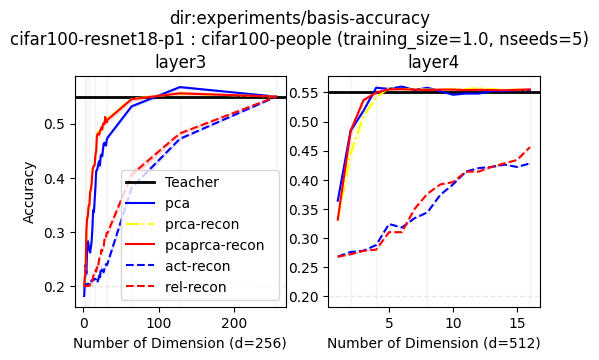

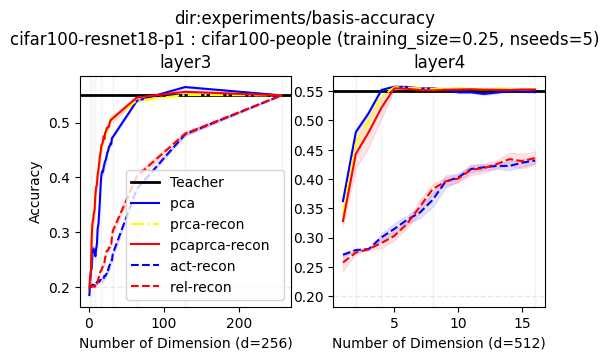

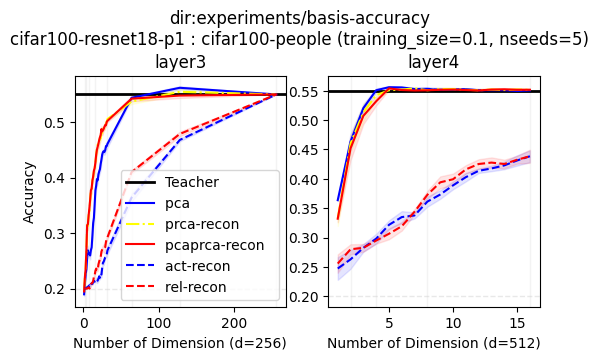

In [151]:
for training_size in [1.0, 0.25, 0.1]:
    accuracy_curve(
        arch="cifar100-resnet18-p1",
        dataset="cifar100-people",
        training_size=training_size,
        layers_and_factors = [
            ("layer3", 1),
            ("layer4", 32)
        ],
        arr_bases=[
            "pca",
            "prca-recon",
            "pcaprca-recon",
            "act-recon",
            "rel-recon"
        ]
    )

## Comparison among prca variance

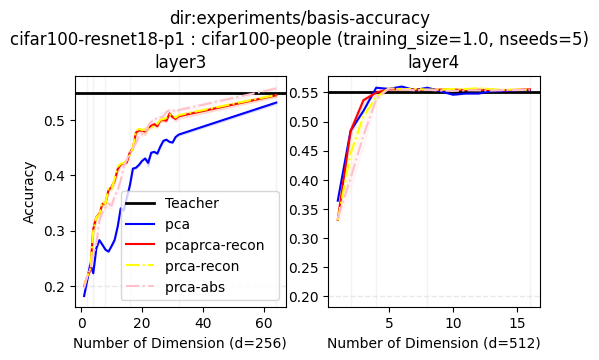

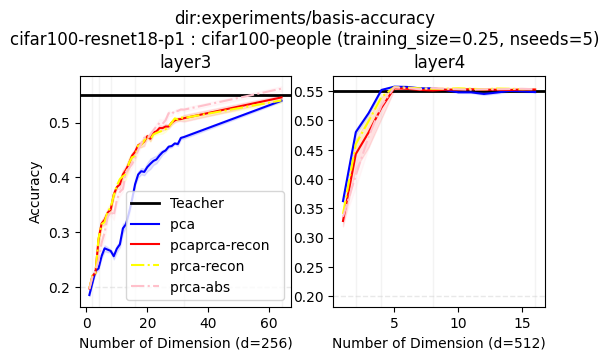

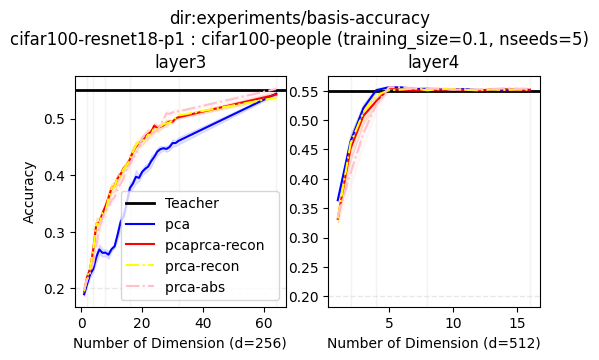

In [139]:
for training_size in [1.0, 0.25, 0.1]:
    accuracy_curve(
        arch="cifar100-resnet18-p1",
        dataset="cifar100-people",
        training_size=training_size,
        arr_bases=[
            "pca",
            "pcaprca-recon",
            "prca-recon",
            "prca-abs",
        ],
        layers_and_factors = [
            ("layer3", 4),
            ("layer4", 32)
        ]
    )

## Comparison between naive and orthogonal complement for Relevance Recon

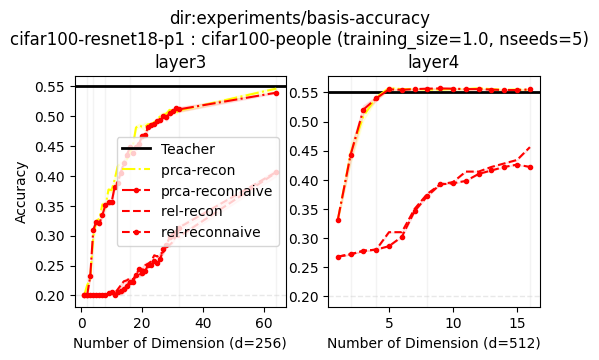

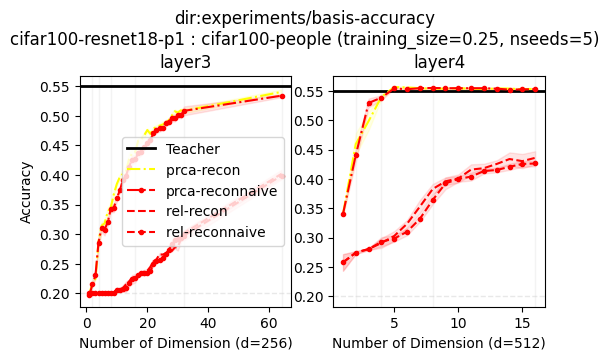

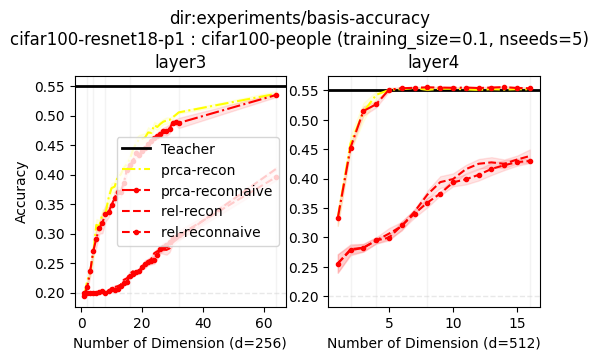

In [150]:
for training_size in [1.0, 0.25, 0.1]:
    accuracy_curve(
        arch="cifar100-resnet18-p1",
        dataset="cifar100-people",
        training_size=training_size,
        arr_bases=[
#             "pca",
            "prca-recon",
            "prca-reconnaive",
#             "pcaprca-recon",

            "rel-recon",
            'rel-reconnaive'
        ],
        layers_and_factors = [
            ("layer3", 4),
            ("layer4", 32)
        ]
    )

## Comparison of Canonical Coordinates

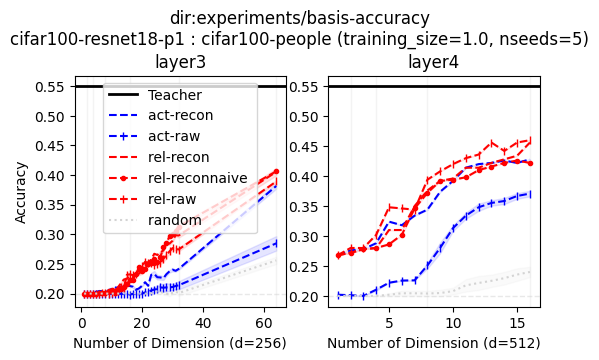

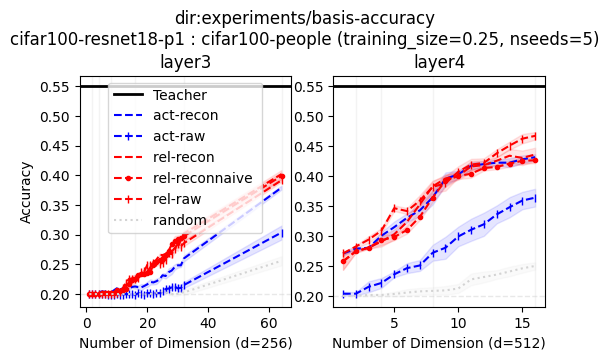

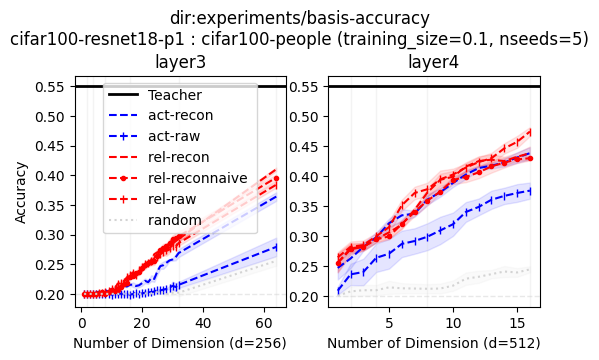

In [141]:
for training_size in [1.0, 0.25, 0.1]:
    accuracy_curve(
        arch="cifar100-resnet18-p1",
        dataset="cifar100-people",
        training_size=training_size,
        arr_bases=[
#             "pca",
            "act-recon",
            "act-raw",
            "rel-recon",
            'rel-reconnaive',
            "rel-raw",
            "random"
        ],
        layers_and_factors = [
            ("layer3", 4),
            ("layer4", 32)
        ]
    )

# Summary: CIFAR100-resnet18-p1

**Aims**:
1. Variant of PRCA
1. Variation in estimating PRCA and PCA
2. Comparing between naive recon and orthogonal complements


**Conclusions**
1. Comparison of PRCA variants
    1. Among Variant of PRCA. PCAPRCA-recon is the best. This variant includes: PRCA-recon + Orthogonal Complement and Precondition with PCA.
    2. `PRCA-Recon` (with Orthogonal Complement) and `PRCA-ReconNaive` behave quite similar on `traning-size=1.0` but the PRCA-Recon seems outperforms on when training size is small.
       - Canonical variant: The effect of orthogonal complement is latter small in the case of `Rel-Recon` and `Rel-ReconNaive`. But, it is NOT conclusive whether `Rel-Recon` is better than soring raw relevance `Rel-Raw`. 
2. Comparison betwen PCA and PRCA (PCAPRCA-Recon)
    1. *Layer3*: PRCA is better.
    2. *Layer4*: PCA is better.

# Replication on CIFAR100-Resnet18-wb15

## Relevance-based Approaches: Naive vs Orthogonal Complement Approaches

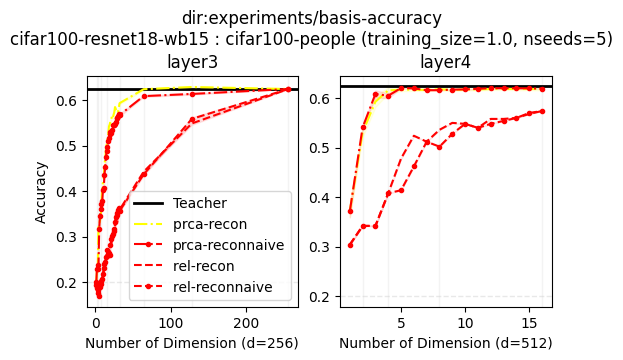

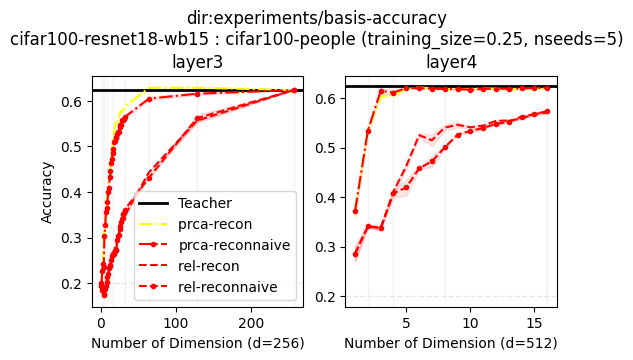

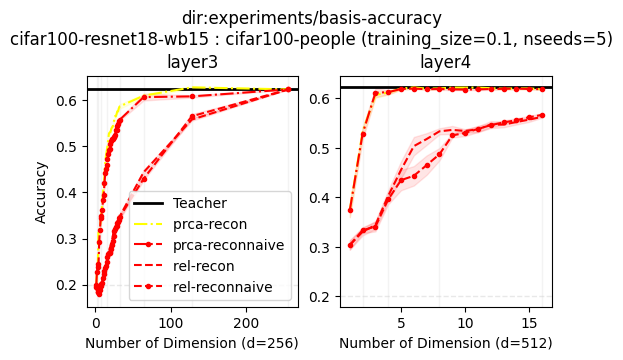

In [142]:
for training_size in [1.0, 0.25, 0.1]:
    accuracy_curve(
        arch="cifar100-resnet18-wb15",
        dataset="cifar100-people",
        training_size=training_size,
        layers_and_factors = [
            ("layer3", 1),
            ("layer4", 32)
        ],
       arr_bases=[
            "prca-recon",
            "prca-reconnaive",    
            "rel-recon",
           "rel-reconnaive",
        ],
    )

## PRCA-Variant

Expected: PCAPRCA-Recon is the best

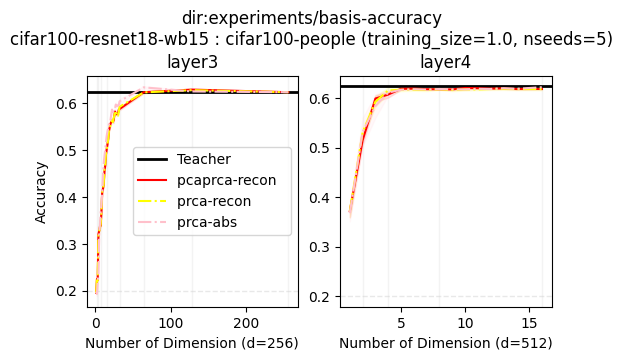

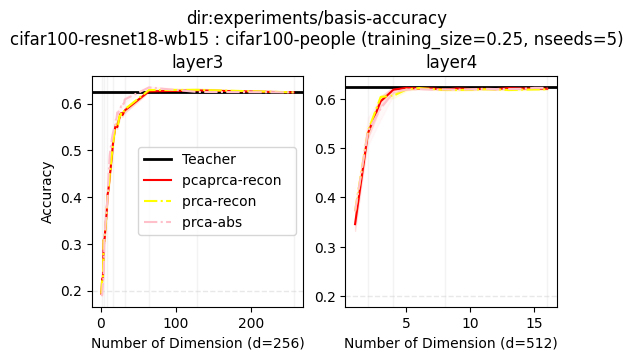

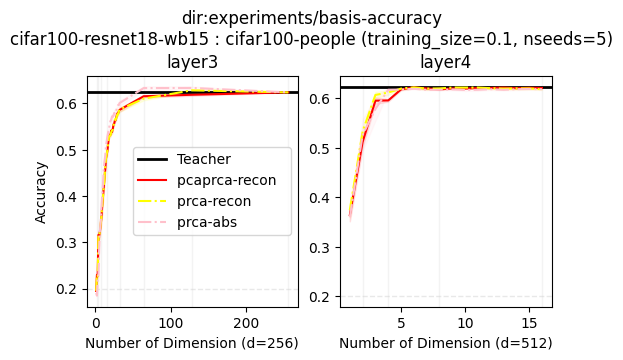

In [143]:
for training_size in [1.0, 0.25, 0.1]:
    accuracy_curve(
        arch="cifar100-resnet18-wb15",
        dataset="cifar100-people",
        training_size=training_size,
        layers_and_factors = [
            ("layer3", 1),
            ("layer4", 32)
        ],
       arr_bases=[
            "pcaprca-recon",
            "prca-recon",
            "prca-abs",
        ],
    )

## PCAPRCA-Recon vs PCA

Expected: PRCA is better at Layer3, while PCA is better at Layer4.

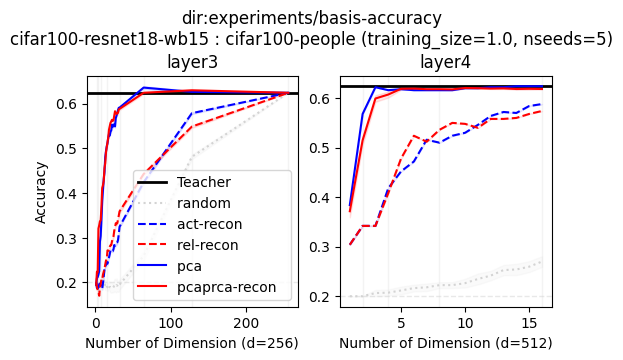

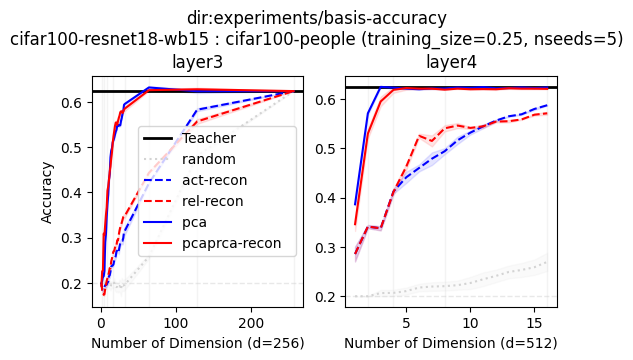

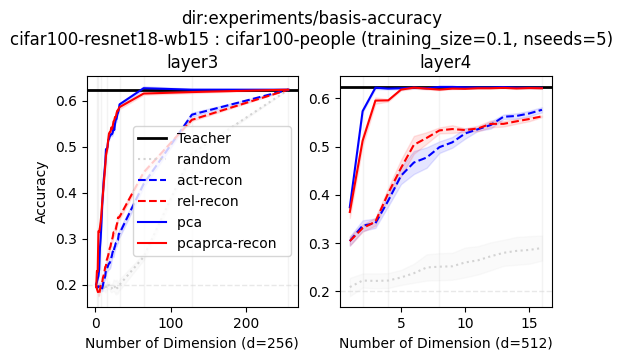

In [146]:
for training_size in [1.0, 0.25, 0.1]:
    accuracy_curve(
        arch="cifar100-resnet18-wb15",
        dataset="cifar100-people",
        training_size=training_size,
        layers_and_factors = [
            ("layer3", 1),
            ("layer4", 32)
        ],
    )

## Summary

For `cifar100-resnet18-wb15`, PRCA is NOT better than PCA. 

# Replication on Traninging Size=1.0 on CIFAR-ResNet18-{p1,wb15, wb11, wb22}

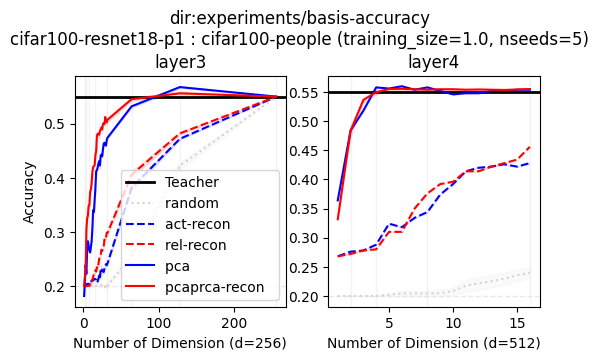

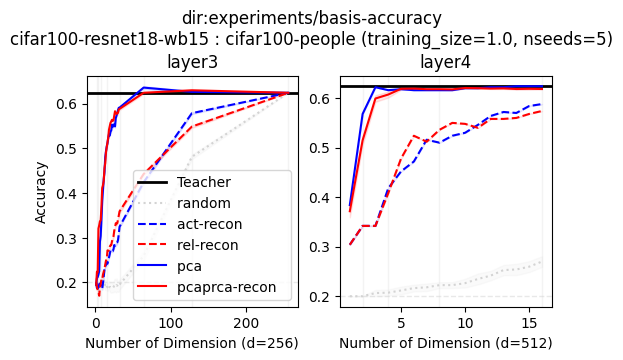

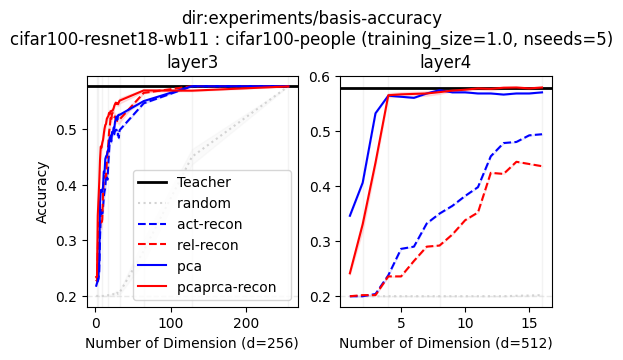

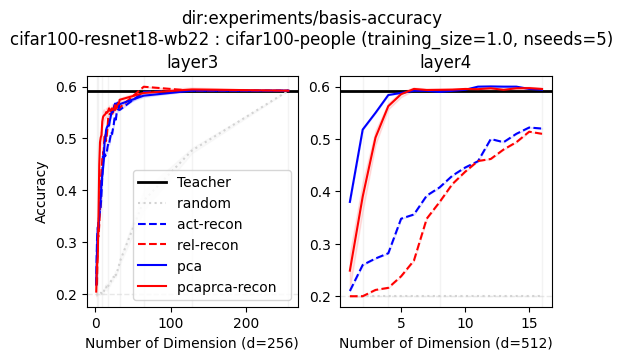

In [163]:
for model_name in [
    "cifar100-resnet18-p1",
    "cifar100-resnet18-wb15",
    "cifar100-resnet18-wb11",
    "cifar100-resnet18-wb22"
]:
    accuracy_curve(
        arch=model_name,
        dataset="cifar100-people",
        training_size=1.0,
        layers_and_factors = [
            ("layer3", 1),
            ("layer4", 32)
        ],
    )